In [1]:
# Импорт библиотек, дополняйте ячейку по своему желанию
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import metrics

# Опции пандаса, чтобы датасеты отображались в полном виде
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
import plotly.express as px
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
import umap

c:\Users\Dasha\Desktop\ML_hakaton\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_excel('./incidents_2000.xlsx')
df.head()

,Тип предприятия,Код предприятия,Количество хостов,Код реализованной угрозы,Успех,Регион размещения предприятия,Дата инцидента,Региональное время
0,НКО,1825,251,190,1,Республика Марий,02.04.2024,02.04.2024 07:47
1,химия,8936,378,152,1,Республика Адыгея,03.03.2023,03.03.2023 05:13
2,отели,8280,1432,7,0,Севастополь,09.05.2025,09.05.2025 10:28
3,фармацевтика,4558,1857,223,0,Смоленская область,15.05.2025,15.05.2025 13:17
4,энергетика,3528,1763,87,0,Архангельская область,17.02.2025,17.02.2025 06:22


In [3]:
data = pd.read_excel('./ФСТЭК.xlsx', header=1)
data.head()

,Идентификатор УБИ,Наименование УБИ,Описание,Источник угрозы (характеристика и потенциал нарушителя),Объект воздействия,Нарушение конфиденциальности,Нарушение целостности,Нарушение доступности,Дата включения угрозы в БнД УБИ,Дата последнего изменения данных,Статус угрозы,Замечания
0,1,Угроза автоматического распространения вредоно...,Угроза заключается в возможности внедрения и з...,Внешний нарушитель со средним потенциалом; Вну...,Ресурсные центры грид-системы,1,1,1,2015-03-20,2019-02-08,Опубликована,NaN
1,2,"Угроза агрегирования данных, передаваемых в гр...",Угроза заключается в возможности раскрытия нар...,Внешний нарушитель со средним потенциалом,Сетевой трафик,1,0,0,2015-03-20,2019-02-08,Опубликована,NaN
2,3,Угроза использования слабостей криптографическ...,Угроза заключается в возможности выявления сла...,Внешний нарушитель со средним потенциалом; Вну...,"Метаданные, системное программное обеспечение",1,1,0,2015-03-20,2020-11-29,Опубликована,NaN
3,4,Угроза аппаратного сброса пароля BIOS,Угроза заключается в возможности сброса пароле...,Внутренний нарушитель с низким потенциалом,Микропрограммное и аппаратное обеспечение BIOS...,0,1,0,2015-03-20,2019-02-08,Опубликована,NaN
4,5,Угроза внедрения вредоносного кода в BIOS,Угроза заключается в возможности заставить BIO...,Внутренний нарушитель с высоким потенциалом,Микропрограммное и аппаратное обеспечение BIOS...,1,1,1,2015-03-20,2019-02-08,Опубликована,NaN


In [4]:
df = df.merge(
    data,
    left_on="Код реализованной угрозы",
    right_on="Идентификатор УБИ",
    how="left"
)
df.head()

,Тип предприятия,Код предприятия,Количество хостов,Код реализованной угрозы,Успех,Регион размещения предприятия,Дата инцидента,Региональное время,Идентификатор УБИ,Наименование УБИ,Описание,Источник угрозы (характеристика и потенциал нарушителя),Объект воздействия,Нарушение конфиденциальности,Нарушение целостности,Нарушение доступности,Дата включения угрозы в БнД УБИ,Дата последнего изменения данных,Статус угрозы,Замечания
0,НКО,1825,251,190,1,Республика Марий,02.04.2024,02.04.2024 07:47,190,Угроза внедрения вредоносного кода за счет пос...,Угроза заключается в возможности осуществления...,Внешний нарушитель со средним потенциалом,Сетевое программное обеспечение,1,1,1,2016-10-21,2019-02-08,Опубликована,NaN
1,химия,8936,378,152,1,Республика Адыгея,03.03.2023,03.03.2023 05:13,152,Угроза удаления аутентификационной информации,Угроза заключается в возможности отказа легити...,Внешний нарушитель с низким потенциалом; Внутр...,"Системное программное обеспечение, микропрогра...",1,1,1,2015-03-20,2019-02-11,Опубликована,NaN
2,отели,8280,1432,7,0,Севастополь,09.05.2025,09.05.2025 10:28,7,Угроза воздействия на программы с высокими при...,Угроза заключается в возможности повышения нар...,Внешний нарушитель со средним потенциалом; Вну...,"Информационная система, виртуальная машина, се...",1,1,0,2015-03-20,2019-02-08,Опубликована,NaN
3,фармацевтика,4558,1857,223,0,Смоленская область,15.05.2025,15.05.2025 13:17,223,Угроза несанкционированного доступа к контейне...,Угроза заключается в возможности осуществления...,Внешний нарушитель с низким потенциалом; Внутр...,Docker-контейнер,1,1,1,2025-06-04,2025-06-04,Опубликована,NaN
4,энергетика,3528,1763,87,0,Архангельская область,17.02.2025,17.02.2025 06:22,87,Угроза несанкционированного использования прив...,Угроза заключается в возможности использования...,Внешний нарушитель с высоким потенциалом; Внут...,"Аппаратное обеспечение, микропрограммное обесп...",1,1,1,2015-03-20,2019-02-11,Опубликована,NaN


In [5]:
df = df[df['Статус угрозы'] != 'Архивная']

In [6]:
df[['Количество хостов', 'Регион размещения предприятия', 'Тип предприятия']] = df\
    .groupby('Код предприятия')[['Количество хостов', 'Регион размещения предприятия', 'Тип предприятия']]\
    .transform('first')

In [7]:
df['Дата инцидента'] = pd.to_datetime(df['Дата инцидента'], format="%d.%m.%Y")
df['Год'] = df['Дата инцидента'].dt.year
df['Месяц'] = df['Дата инцидента'].dt.month
df['День'] = df['Дата инцидента'].dt.day
df['День недели'] = df['Дата инцидента'].dt.weekday

df = df.drop(['Дата инцидента', 'Региональное время', 'Код предприятия', 'Идентификатор УБИ', 
            'Дата включения угрозы в БнД УБИ', 'Дата последнего изменения данных', 'Статус угрозы', 
            'Замечания', 'Наименование УБИ', 'Описание'], axis=1)

In [8]:
df = df.dropna()
df = df.reset_index(drop=True)

In [9]:
df['Объект воздействия'] = df['Объект воздействия'].str.split(', ')
df['Источник угрозы (характеристика и потенциал нарушителя)'] = df['Источник угрозы (характеристика и потенциал нарушителя)'].str.split('; ')

In [10]:
mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(df['Объект воздействия'])
encoded_df = pd.DataFrame(encoded, columns=mlb.classes_)

In [11]:
mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(df['Источник угрозы (характеристика и потенциал нарушителя)'])
encoded_df = pd.DataFrame(encoded, columns=mlb.classes_)

In [12]:
df = df.drop(['Объект воздействия', 'Источник угрозы (характеристика и потенциал нарушителя)'], axis=1)
df = pd.concat([df, encoded_df], axis=1)

In [13]:
ohe = OneHotEncoder()
row_data = ohe.fit_transform(df[['Тип предприятия']]).toarray()
df_one_hot = pd.DataFrame(row_data, columns=[i[j] for i in ohe.categories_ for j in range(len(i))])
df = pd.concat([df, df_one_hot], axis=1)
df = df.drop(['Тип предприятия'], axis=1)

In [14]:
freq = df['Регион размещения предприятия'].value_counts(normalize=True)
df['Регион размещения предприятия'] = df['Регион размещения предприятия'].map(freq)

In [15]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

In [16]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

In [17]:
k_range = range(2, 10)
scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, labels))

C:\Users\Dasha\AppData\Local\Temp\ipykernel_9888\1010147062.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


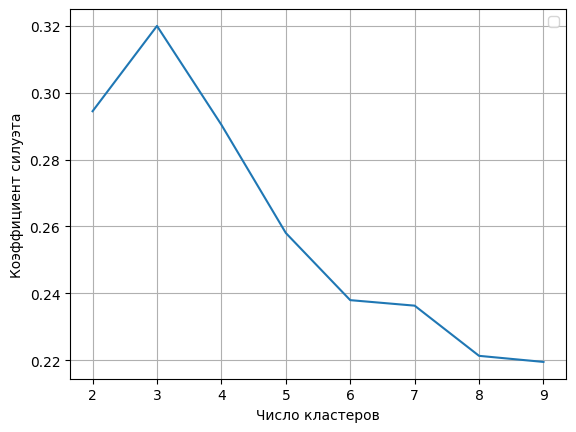

In [18]:
plt.plot(k_range, scores)
plt.xlabel('Число кластеров')
plt.ylabel('Коэффициент силуэта')
plt.legend()
plt.grid()

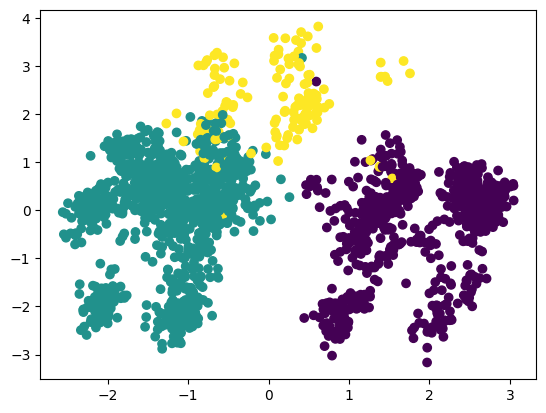

In [19]:
model = KMeans(n_clusters=3, random_state=42)
labels = model.fit_predict(X_pca)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)

In [20]:
df['cluster'] = labels
df['cluster'].value_counts()

cluster
1    1096
0     697
2     140
Name: count, dtype: int64

In [21]:
k_range = range(2, 10)
scores = []

for k in k_range:
    model = AgglomerativeClustering(
    n_clusters=k,
    metric="cosine",
    linkage="average"
)
    labels = model.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, labels))

C:\Users\Dasha\AppData\Local\Temp\ipykernel_9888\1010147062.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


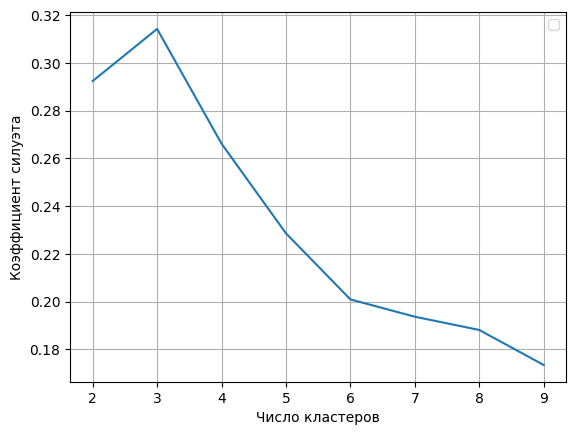

In [22]:
plt.plot(k_range, scores)
plt.xlabel('Число кластеров')
plt.ylabel('Коэффициент силуэта')
plt.legend()
plt.grid()

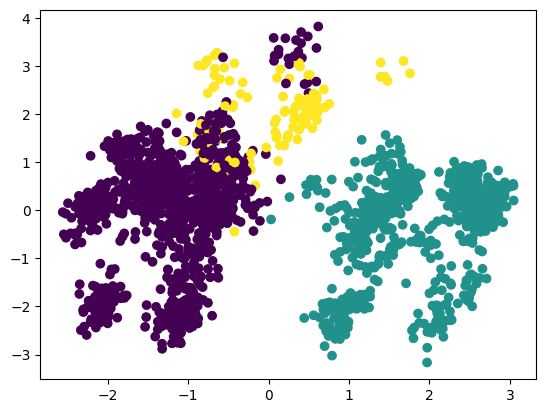

In [23]:
model = AgglomerativeClustering(
    n_clusters=3,
    metric="cosine",
    linkage="average"
)
labels = model.fit_predict(X_pca)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)